In [11]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt

# Exercício 1


uint8
(512, 512, 3)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

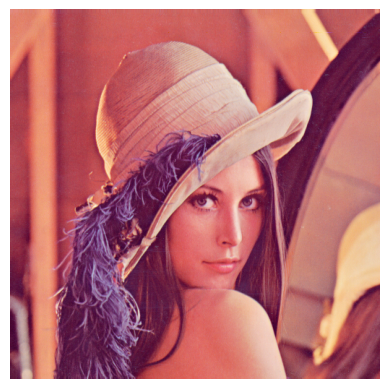

In [12]:
x_img = cv.imread ("lena.tif")
x_img_converted = cv.cvtColor(x_img, cv.COLOR_BGR2RGB)

print(x_img.dtype)
print(x_img.shape)

plt.imshow(x_img_converted)
plt.axis('off')

O método 'dtype' serve para verificar o tipo de dado da variável (exemplo: uint8, String, float).
O método 'shape' serve para mostrar as linhas, colunas e canais da imagem, neste caso, é uma imagem com: 512x512 com 3 canais (RGB)

# Exercício 2

In [13]:
cv.imwrite("file1.jpg" , x_img,(cv.IMWRITE_JPEG_QUALITY, 80))
cv.imwrite("file2.jpg" , x_img,(cv.IMWRITE_JPEG_QUALITY, 10))

True

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

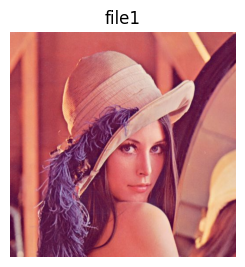

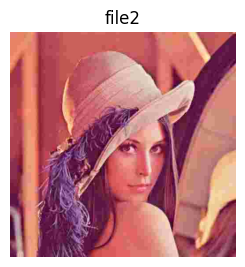

In [14]:
cnvrt = cv.cvtColor(cv.imread("file1.jpg"), cv.COLOR_BGR2RGB)
plt.figure()
plt.subplot(1,2,1)
plt.title("file1")
plt.imshow(cnvrt)
plt.axis("off")

cnvrt2 = cv.cvtColor(cv.imread("file2.jpg"), cv.COLOR_BGR2RGB)
plt.figure()
plt.subplot(1,2,1)
plt.title("file2")
plt.imshow(cnvrt2)
plt.axis("off")

In [15]:
# Converter as duas imagens para float
Ic = x_img * 1.0
Id = cv.imread("file1.jpg") * 1.0

In [16]:
Porg = np.mean(Ic**2)
Perr = np.mean((Ic - Id)**2)
SNR = 10 * np.log10(Porg / Perr)
print(SNR.dtype)
print('SNR (dB): ', SNR)

float64
SNR (dB):  28.468534958720454


In [17]:
PSNR = 10 * np.log10((255**2) / Perr)
print(PSNR.dtype)
print('PSNR (dB): ', PSNR)

float64
PSNR (dB):  33.606097256534746


## Ex 3

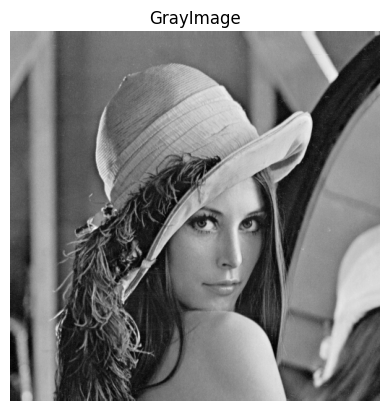

True

In [18]:
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)

plt.imshow(x_img_g, cmap='gray')
plt.title("GrayImage")
plt.axis("off")
plt.show()

cv.imwrite("file3.bmp", x_img_g)



In [19]:
x_img_g = os.path.getsize("./file3.bmp")
x_img_original = os.path.getsize("./lena.tif")
print("Tamanho do arquivo original: ", x_img_original, "bytes")
print("Tamanho do arquivo convertido: ", x_img_g, "bytes")
print("Redução de tamanho: ", x_img_original - x_img_g, "bytes")

Tamanho do arquivo original:  786572 bytes
Tamanho do arquivo convertido:  263222 bytes
Redução de tamanho:  523350 bytes


## EX:4

/tmp/ipykernel_4297/4106981430.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  hist_values = plt.hist(x_img_g.ravel(), 256, [0,256])


Histograma: 3
Níveis de cinzento: 215


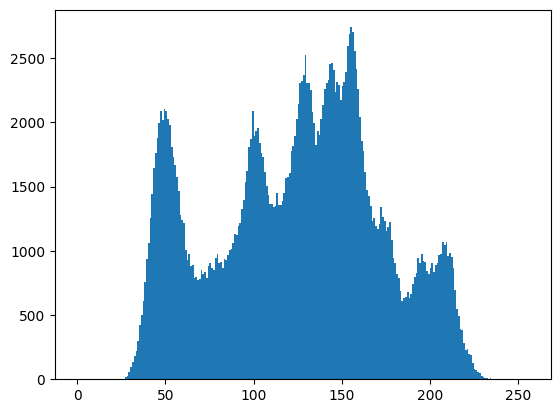

In [20]:
x_img = cv.imread("lena.tif")
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)

hist_values = plt.hist(x_img_g.ravel(), 256, [0,256])

print("Histograma:", len(hist_values))

niveis_cinza = np.sum(hist_values[0] != 0)
print("Níveis de cinzento:", niveis_cinza)

# Exercício 5

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

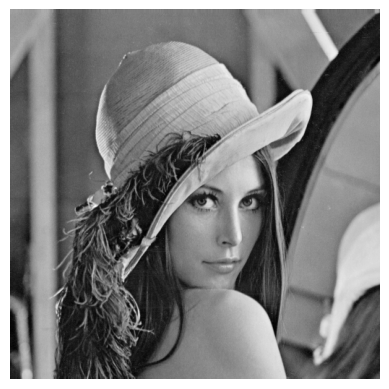

In [21]:
# grayscale
x_img_g = cv.cvtColor(x_img, cv.COLOR_BGR2GRAY)
plt . imshow (x_img_g , cmap = 'gray')
plt.axis('off')

Text(0.5, 1.0, ' bit2 ')

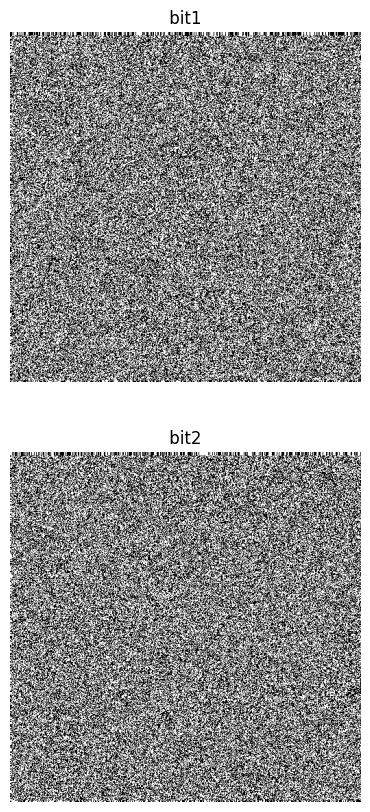

In [22]:
plt.figure(figsize=(20, 10))
plt.subplot(211)
I1 =(x_img_g %2)*255
plt . imshow (I1 , cmap = 'gray')
plt . axis ( 'off' )
plt . title ( ' bit1 ')
plt . subplot (212)
I2 =((x_img_g >> 1) % 2) * 255
plt . imshow (I2 , cmap = 'gray')
plt . axis ( 'off')
plt . title ( ' bit2 ')

# Exercício 6

In [23]:
def dither(x_img_g):
    img = x_img_g * 1.0
    h, w = img.shape

    for y in range(h):
        for x in range(w):
            old_pixel = img[y, x]
            
            new_pixel = 255 if old_pixel > 127.5 else 0
            img[y, x] = new_pixel
            
            quant_error = old_pixel - new_pixel
        
            if x + 1 < w:
                img[y, x+1] += quant_error * 7/16
            
            if y + 1 < h and x - 1 >= 0:
                img[y+1, x-1] += quant_error * 3/16
                
            if y + 1 < h:
                img[y+1, x] += quant_error * 5/16
                
            if y + 1 < h and x + 1 < w:
                img[y+1, x+1] += quant_error * 1/16

    return img.astype(np.uint8)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

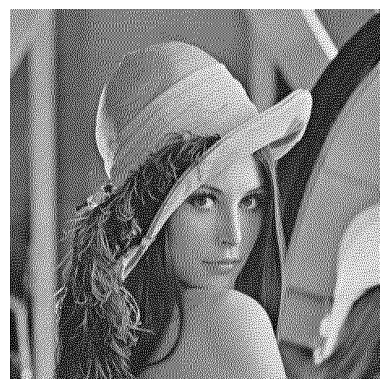

In [24]:
dithered_img = dither(x_img_g)

plt.figure()
plt.imshow(dithered_img, cmap='gray')
plt.axis('off')